In [179]:
import pandas as pd
df_all = pd.read_csv('../LTV-Capstone-Project/mart_all_data.csv')

In [180]:
df_all.columns

Index(['customer_id', 'customer_gender', 'customer_location',
       'customer_tenure_months', 'transaction_id', 'transaction_date',
       'produkt_sku', 'product_category', 'quantity', 'avg_price',
       'delivery_charges', 'coupon_status', 'discount_pct', 'gst_onsale',
       'offline_spend_that_day', 'online_spend_that_day', 'transaction_year',
       'transaction_month', 'transaction_month_str',
       'transaction_day_of_month', 'transaction_day_of_week'],
      dtype='object')

In [181]:
df_holidays = pd.read_csv('../LTV-Capstone-Project/mart_holidays_2019_us.csv')

In [182]:
df_holidays.columns

Index(['name', 'description', 'date', 'type'], dtype='object')

In [183]:
df_all['transaction_date'] = pd.to_datetime(df_all['transaction_date']).dt.normalize()
df_holidays['date'] = pd.to_datetime(df_holidays['date']).dt.normalize()

In [184]:
df_merged = df_all.merge(df_holidays, left_on='transaction_date', right_on='date', how='left')


In [185]:
df_merged = df_merged.drop(columns=['date'])


In [186]:
#Create holiday indicator column
df_merged['is_holiday'] = df_merged['name'].notnull()


In [187]:
# Create dummies by holiday type
holiday_type_dummies = pd.get_dummies(df_merged['type'], prefix='holiday_type', dummy_na=True)
df_merged = pd.concat([df_merged, holiday_type_dummies], axis=1)

In [188]:
df_merged.columns

Index(['customer_id', 'customer_gender', 'customer_location',
       'customer_tenure_months', 'transaction_id', 'transaction_date',
       'produkt_sku', 'product_category', 'quantity', 'avg_price',
       'delivery_charges', 'coupon_status', 'discount_pct', 'gst_onsale',
       'offline_spend_that_day', 'online_spend_that_day', 'transaction_year',
       'transaction_month', 'transaction_month_str',
       'transaction_day_of_month', 'transaction_day_of_week', 'name',
       'description', 'type', 'is_holiday', 'holiday_type_Christian',
       'holiday_type_Clock change/Daylight Saving Time', 'holiday_type_Hebrew',
       'holiday_type_Hinduism', 'holiday_type_Local holiday',
       'holiday_type_Local holiday, Christian',
       'holiday_type_Local observance', 'holiday_type_Muslim',
       'holiday_type_National holiday',
       'holiday_type_National holiday, Christian', 'holiday_type_Observance',
       'holiday_type_Observance, Christian', 'holiday_type_Orthodox',
       'holida

In [209]:
ltv_final = pd.read_csv('../LTV-Capstone-Project/Customer_LTV_Summary.csv')

In [210]:
ltv_final.columns = ltv_final.columns.str.lower()

In [212]:
ltv_final = ltv_final.rename(columns={'customerid': 'customer_id'})

In [213]:
ltv_final.columns

Index(['customer_id', 'frequency', 'recency', 't', 'monetary_value',
       'predicted_purchases_6m', 'predicted_avg_value', 'predicted_ltv_6m',
       'gender', 'location', 'tenure_months'],
      dtype='object')

In [224]:
# Step 1: Create dummies for holiday names
holiday_name_dummies = pd.get_dummies(df_merged['name'], prefix='holiday_name', dummy_na=False)

# Step 2: Add customer_id and group by customer
holiday_name_flags = pd.concat([df_merged['customer_id'], holiday_name_dummies], axis=1)
holiday_name_flags = holiday_name_flags.groupby('customer_id').max().reset_index()

# Step 3: Merge holiday flags (types + names) into ltv_final
ltv_holiday = ltv_final.merge(holiday_flags, on='customer_id', how='left')
ltv_holiday = ltv_holiday.merge(holiday_type_flags, on='customer_id', how='left')
ltv_holiday = ltv_holiday.merge(holiday_name_flags, on='customer_id', how='left')

# Step 4: Fill NaNs for all holiday indicators
ltv_holiday['is_holiday'] = ltv_holiday['is_holiday'].fillna(0)

# Fill holiday types
for col in holiday_type_flags.columns:
    if col != 'customer_id':
        ltv_holiday[col] = ltv_holiday[col].fillna(0)

# Fill holiday names
for col in holiday_name_flags.columns:
    if col != 'customer_id':
        ltv_holiday[col] = ltv_holiday[col].fillna(0)

holiday_name_dummies.columns = holiday_name_dummies.columns.str.replace('[^0-9a-zA-Z_]', '_', regex=True)


C:\Users\dbyst\AppData\Local\Temp\ipykernel_24752\2257317506.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  no_holiday = ltv_mean.get(0, 0)
C:\Users\dbyst\AppData\Local\Temp\ipykernel_24752\2257317506.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  with_holiday = ltv_mean.get(1, 0)


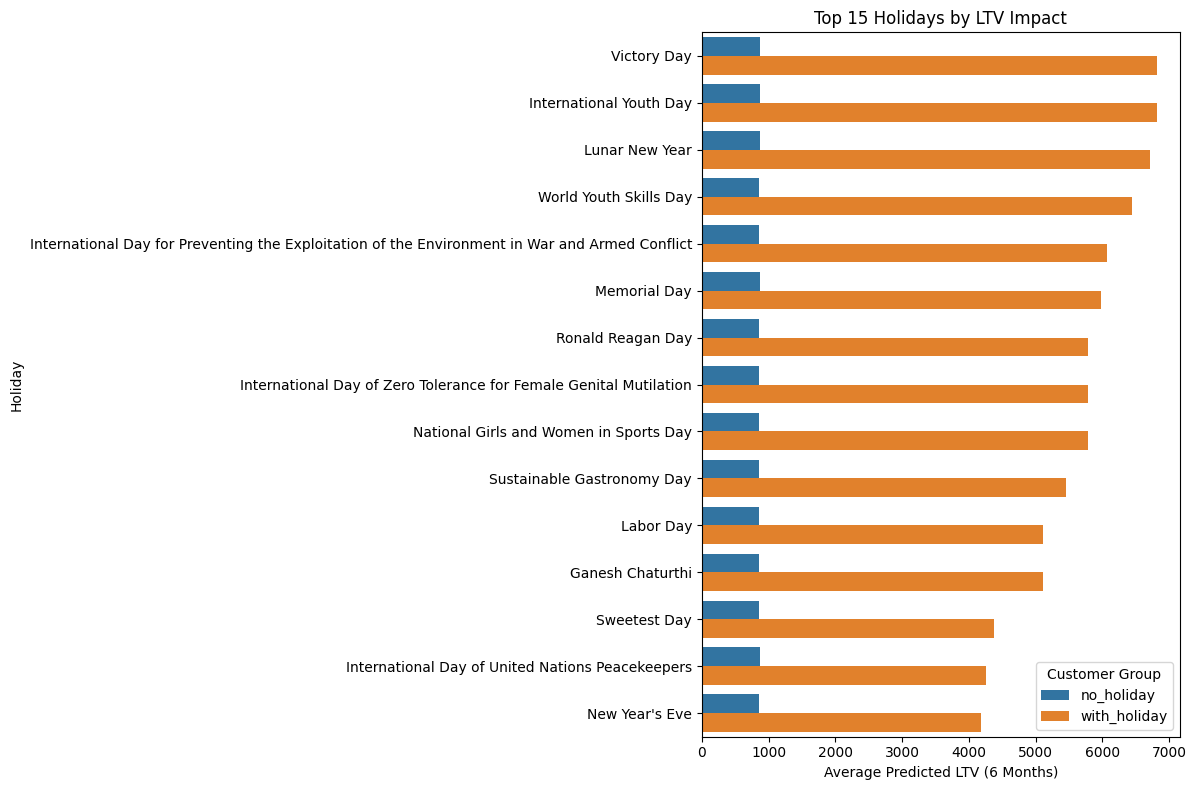

In [226]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify holiday name columns
holiday_name_cols = [col for col in ltv_holiday.columns if col.startswith('holiday_name_')]

# Prepare DataFrame with LTV differences
holiday_ltv_impact = []

for col in holiday_name_cols:
    ltv_mean = ltv_holiday.groupby(col)['predicted_ltv_6m'].mean()
    no_holiday = ltv_mean.get(0, 0)
    with_holiday = ltv_mean.get(1, 0)
    diff = with_holiday - no_holiday
    holiday_ltv_impact.append({
        'holiday': col.replace('holiday_name_', '').replace('_', ' '),
        'no_holiday': no_holiday,
        'with_holiday': with_holiday,
        'ltv_diff': diff
    })

# Create DataFrame and get top 15 by absolute LTV difference
impact_df = pd.DataFrame(holiday_ltv_impact)
top15 = impact_df.reindex(impact_df['ltv_diff'].abs().sort_values(ascending=False).index).head(15)

# Melt for plotting
impact_melted = top15.melt(id_vars='holiday', value_vars=['no_holiday', 'with_holiday'],
                           var_name='group', value_name='avg_ltv')

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=impact_melted, x='avg_ltv', y='holiday', hue='group')
plt.title('Top 15 Holidays by LTV Impact')
plt.xlabel('Average Predicted LTV (6 Months)')
plt.ylabel('Holiday')
plt.legend(title='Customer Group')
plt.tight_layout()
plt.show()


Y-axis (Holiday): The top 15 holidays where purchase behavior had the largest difference in LTV, based on whether a customer made a purchase on that day.
X-axis (Average Predicted LTV in $ or units): The average 6-month predicted LTV for two groups:
"no_holiday": Customers who did not make purchases during that holiday.
"with_holiday": Customers who did make purchases during that holiday.

Bars: Each holiday has two bars:
One for average LTV of non-participants in that holiday.
One for participants (customers who purchased during that holiday).
Sort Order: Holidays are sorted by the largest absolute LTV difference, showing where the holiday had the most significant impact on customer value.

INTERPRETATION

If the “with_holiday” bar is much higher, it suggests:
Customers who shopped on this holiday are significantly more valuable over the next 6 months.
If it’s lower, it might mean:
Holiday shoppers were more opportunistic (e.g., deal seekers) and didn’t return often.
If the bars are similar:
The holiday didn’t have a major effect on customer future value.

e.g. Customers who made purchases on Victory Day tend to spend more or return more often, and may be a high-value segment worth targeting again next year.